# Lake Okeechobee Seasonal Flow Prediction Training Notebook

This cleaned notebook is designed for a training class. It uses a simple, readable workflow to:

1. load and prepare the data,
2. create a November–April water-year summary,
3. train a **Linear Regression** model for continuous prediction,
4. train a **Logistic Regression** model for a simple high-flow / low-flow classification task,
5. train a **Random Forest Regressor**,
6. train an **XGBoost Regressor**, and
7. compare regression model performance.

The notebook keeps comments that explain *why* each step is being done, without extra experimental code.


# Disclaimer: 
Portions of this code were developed with assistance from ChatGPT and were subsequently reviewed, edited, 
and organized for instructional use. The code is provided as a teaching example only and has not been fully
validated for professional engineering, regulatory, design, or safety-critical applications. Users are responsible 
for independently checking assumptions, data quality, parameter choices, numerical results, and suitability 
for any specific water resources application.

In [2]:
## Core libraries for data handling and plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn tools for model training and evaluation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import clone

# XGBoost model
from xgboost import XGBRegressor

# Make plots a little larger for training/demo use
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True


## 1) Load the input data

This example reads the CSV file used by the original notebook.  
Only the columns needed for this training example are retained.


In [5]:
# Load the source data
df = pd.read_csv("./LOKdat.csv")
print(df.columns)
# Select a small set of climate predictors plus the target variable
selected_columns = [
    "Year",
    "Month",
    "AMO",
    "ENSO_NINO.34",
    "LakeO_flow",
    "NAO",
    "UKR",
    "LKR",
    "LOK",
]

df = df[selected_columns].copy()

# Keep the modern analysis period used in the original notebook
df = df[df["Year"] >= 1960].copy()

print("Data shape after filtering:", df.shape)
display(df.head())


Index(['Year', 'Month', 'Int.Sunspot.Number', 'Int.Sunspot.Number.Smoothed',
       'PDO', 'AMO', 'ENSO_NINO.34', 'NiNO3Ext', 'ENSO_ONI', 'AA_Orig',
       'AA_Adj', 'AA_12month', 'LakeO_flow', 'NAO', 'Rainfall_PRISM',
       'Rainfall_CD4', 'Rainfall_CD5', 'Rainfall_CD6', 'AMOGray', 'KG2', 'UKR',
       'LKR', 'LOK', 'ECAL', 'UEC', 'Nino34Off'],
      dtype='object')
Data shape after filtering: (668, 9)


,Year,Month,AMO,ENSO_NINO.34,LakeO_flow,NAO,UKR,LKR,LOK
2532,1960,1,0.19,-0.13,96.0,-2.0,0.89,0.43,0.35
2533,1960,2,0.23,-0.27,319.0,-3.3,4.18,5.18,5.23
2534,1960,3,0.10,0.20,213.0,-0.8,8.66,5.45,3.85
2535,1960,4,0.11,0.23,317.0,1.5,5.10,3.19,2.78
2536,1960,5,0.31,0.17,62.0,0.0,3.49,2.86,3.33


## 2) Create a water year and seasonal averages

Here, the **water year** rolls over in October, and we keep only the
**November–April** months before averaging values by water year.


In [8]:
# Create a water year column:
# Months Oct-Dec are assigned to the following year.
df["WaterYear"] = df["Year"]
df.loc[df["Month"] >= 10, "WaterYear"] = df["Year"] + 1

# Keep only November through April for this seasonal predictor set
season_months = [11, 12, 1, 2, 3, 4]
season_df = df[df["Month"].isin(season_months)].copy()

# Aggregate to one row per water year using the mean of numeric columns
agg_df = season_df.groupby("WaterYear").mean(numeric_only=True).reset_index()

print("Aggregated seasonal data shape:", agg_df.shape)
display(agg_df.head())


Aggregated seasonal data shape: (56, 10)


,WaterYear,Year,Month,AMO,ENSO_NINO.34,LakeO_flow,NAO,UKR,LKR,LOK
0,1960,1960.000000,2.5,0.157500,0.007500,236.250000,-1.150000,4.707500,3.562500,3.052500
1,1961,1960.666667,5.5,0.161667,-0.003333,109.833333,0.583333,1.890000,1.810000,1.500000
2,1962,1961.666667,5.5,0.150000,-0.251667,-54.833333,-0.916667,1.381667,1.563333,1.416667
3,1963,1962.666667,5.5,0.143333,-0.263333,-67.500000,-1.316667,2.771667,1.981667,1.611667
4,1964,1963.666667,5.5,-0.038333,0.486667,79.166667,-1.133333,4.193333,3.005000,2.706667


## 3) Build the modeling table

We predict **LakeO_flow** using the remaining climate variables.
Missing predictor values are filled with the column mean.


In [11]:
# Keep only rows where the target is available
model_df = agg_df[agg_df["LakeO_flow"].notna()].copy()

# Define predictors (X) and target (y)
X = model_df.drop(columns=["LakeO_flow", "WaterYear", "Year", "Month"])
y = model_df["LakeO_flow"]

# Fill missing predictor values with the mean of each column
X = X.fillna(X.mean())

print("Predictor columns:", list(X.columns))
print("Number of samples:", len(X))
display(X.head())


Predictor columns: ['AMO', 'ENSO_NINO.34', 'NAO', 'UKR', 'LKR', 'LOK']
Number of samples: 55


,AMO,ENSO_NINO.34,NAO,UKR,LKR,LOK
0,0.157500,0.007500,-1.150000,4.707500,3.562500,3.052500
1,0.161667,-0.003333,0.583333,1.890000,1.810000,1.500000
2,0.150000,-0.251667,-0.916667,1.381667,1.563333,1.416667
3,0.143333,-0.263333,-1.316667,2.771667,1.981667,1.611667
4,-0.038333,0.486667,-1.133333,4.193333,3.005000,2.706667


## 4) Train/test split

A random split is used here because the original notebook used a standard train/test split.
For a forecasting-only workflow, a time-based split could also be considered.


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 44
Testing samples: 11


## 5) Helper functions

These small functions keep the notebook cleaner and make model comparison easier.


In [17]:
def evaluate_regression_model(model_name, y_true, y_pred):
    """Print basic regression metrics and return them as a dictionary."""
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f"{model_name} performance")
    print(f"  R²   = {r2:.3f}")
    print(f"  RMSE = {rmse:.3f}")

    return {"Model": model_name, "R2": r2, "RMSE": rmse}


def plot_observed_vs_predicted(y_true, y_pred, title):
    """Scatter plot of observed vs predicted values."""
    plt.figure()
    plt.scatter(y_true, y_pred)
    plt.xlabel("Observed LakeO_flow")
    plt.ylabel("Predicted LakeO_flow")
    plt.title(title)

    # 1:1 reference line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val])
    plt.show()


def plot_residuals(y_true, y_pred, title):
    """Residual plot to show where the model over- or under-predicts."""
    residuals = y_true - y_pred

    plt.figure()
    plt.scatter(y_pred, residuals)
    plt.axhline(0)
    plt.xlabel("Predicted LakeO_flow")
    plt.ylabel("Residual (Observed - Predicted)")
    plt.title(title)
    plt.show()


def plot_test_set_predictions(y_true, prediction_dict, sample_labels=None, title="Observed and predicted values on the test set"):
    """Plot observed values and multiple model predictions on the same axes."""
    plot_df = pd.DataFrame({"Observed": pd.Series(y_true).reset_index(drop=True)})

    for model_name, preds in prediction_dict.items():
        plot_df[model_name] = np.asarray(preds)

    if sample_labels is None:
        x_values = np.arange(len(plot_df))
        x_label = "Test sample"
    else:
        x_values = np.asarray(sample_labels)
        x_label = "Water Year"

    plt.figure(figsize=(10, 5))
    plt.plot(x_values, plot_df["Observed"], marker="o", label="Observed")

    for column in plot_df.columns[1:]:
        plt.plot(x_values, plot_df[column], marker="o", label=column)

    plt.xlabel(x_label)
    plt.ylabel("LakeO_flow")
    plt.title(title)
    plt.legend()
    plt.show()

    return plot_df


def plot_feature_importance(importances, feature_names, title):
    """Simple horizontal bar chart for feature importance."""
    importance_df = (
        pd.DataFrame({"Feature": feature_names, "Importance": importances})
        .sort_values("Importance", ascending=True)
    )

    plt.figure(figsize=(8, 5))
    plt.barh(importance_df["Feature"], importance_df["Importance"])
    plt.xlabel("Importance")
    plt.title(title)
    plt.show()

    return importance_df.sort_values("Importance", ascending=False).reset_index(drop=True)


def evaluate_classification_model(model_name, y_true, y_pred):
    """Print a simple classification metric and return it as a dictionary."""
    accuracy = accuracy_score(y_true, y_pred)

    print(f"{model_name} performance")
    print(f"  Accuracy = {accuracy:.3f}")

    return {"Model": model_name, "Accuracy": accuracy}


def plot_confusion_matrix_for_classification(y_true, y_pred, title, class_labels):
    """Plot a confusion matrix for a classification example."""
    cm = confusion_matrix(y_true, y_pred, labels=class_labels)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_labels
    )
    disp.plot()
    plt.title(title)
    plt.show()

def summarize_grid_search_results(grid_search, top_n=10):
    """Return the best combinations from a GridSearchCV object."""
    results = pd.DataFrame(grid_search.cv_results_).copy()
    results["CV_RMSE"] = -results["mean_test_score"]

    summary = results[["rank_test_score", "CV_RMSE", "std_test_score", "params"]]
    summary = summary.sort_values(["rank_test_score", "CV_RMSE"]).reset_index(drop=True)
    return summary.head(top_n)


def compute_rf_prediction_intervals(rf_model, X_data, lower_q=5, upper_q=95):
    """
    Estimate Random Forest prediction intervals from the spread of the individual trees.
    This is a practical classroom approximation rather than a formal coverage guarantee.
    """
    tree_predictions = np.column_stack(
        [tree.predict(np.asarray(X_data)) for tree in rf_model.estimators_]
    )

    interval_df = pd.DataFrame(
        {
            "Prediction": tree_predictions.mean(axis=1),
            f"Lower_{lower_q}": np.percentile(tree_predictions, lower_q, axis=1),
            f"Upper_{upper_q}": np.percentile(tree_predictions, upper_q, axis=1),
        },
        index=getattr(X_data, "index", None),
    )
    interval_df["Interval_Width"] = (
        interval_df[f"Upper_{upper_q}"] - interval_df[f"Lower_{lower_q}"]
    )
    return interval_df


def compute_bootstrap_prediction_intervals(
    base_model,
    X_train,
    y_train,
    X_data,
    n_members=30,
    lower_q=5,
    upper_q=95,
    random_state=42,
):
    """
    Estimate prediction intervals from an ensemble of bootstrap-refit models.
    This is useful for models such as XGBoost that do not directly expose tree-by-tree
    prediction distributions in the same way as Random Forest.
    """
    rng = np.random.default_rng(random_state)

    X_train_df = X_train if isinstance(X_train, pd.DataFrame) else pd.DataFrame(X_train)
    y_train_series = y_train if isinstance(y_train, pd.Series) else pd.Series(y_train)

    ensemble_predictions = []
    n_train = len(X_train_df)

    for member in range(n_members):
        sample_idx = rng.integers(0, n_train, n_train)
        X_boot = X_train_df.iloc[sample_idx]
        y_boot = y_train_series.iloc[sample_idx]

        model_i = clone(base_model)
        if hasattr(model_i, "random_state"):
            model_i.set_params(random_state=random_state + member)

        model_i.fit(X_boot, y_boot)
        ensemble_predictions.append(model_i.predict(X_data))

    ensemble_predictions = np.column_stack(ensemble_predictions)

    interval_df = pd.DataFrame(
        {
            "Prediction": ensemble_predictions.mean(axis=1),
            f"Lower_{lower_q}": np.percentile(ensemble_predictions, lower_q, axis=1),
            f"Upper_{upper_q}": np.percentile(ensemble_predictions, upper_q, axis=1),
        },
        index=getattr(X_data, "index", None),
    )
    interval_df["Interval_Width"] = (
        interval_df[f"Upper_{upper_q}"] - interval_df[f"Lower_{lower_q}"]
    )
    return interval_df, ensemble_predictions


def summarize_prediction_intervals(model_name, y_true, lower, upper):
    """Summarize how often the observed values fall inside the interval."""
    y_true = np.asarray(y_true)
    lower = np.asarray(lower)
    upper = np.asarray(upper)

    coverage = np.mean((y_true >= lower) & (y_true <= upper))
    mean_width = np.mean(upper - lower)

    print(f"{model_name} uncertainty summary")
    print(f"  Interval coverage = {coverage:.3f}")
    print(f"  Mean interval width = {mean_width:.3f}")

    return {
        "Model": model_name,
        "Coverage": coverage,
        "Mean_Interval_Width": mean_width,
    }


def plot_predictions_with_intervals(
    y_true,
    y_pred,
    lower,
    upper,
    sample_labels=None,
    title="Observed and predicted values with uncertainty bounds",
    interval_label="90% interval",
):
    """Plot observed and predicted values together with lower and upper bounds."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    lower = np.asarray(lower)
    upper = np.asarray(upper)

    if sample_labels is None:
        x_values = np.arange(len(y_true))
        x_tick_values = x_values
        x_label = "Test sample"
    else:
        x_values = np.arange(len(y_true))
        x_tick_values = np.asarray(sample_labels)
        x_label = "Water Year"

    plt.figure(figsize=(10, 5))
    plt.plot(x_values, y_true, marker="o", label="Observed")
    plt.plot(x_values, y_pred, marker="o", label="Predicted")
    plt.fill_between(x_values, lower, upper, alpha=0.25, label=interval_label)
    plt.xticks(x_values, x_tick_values, rotation=45)
    plt.xlabel(x_label)
    plt.ylabel("LakeO_flow")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


## 5a) Practical uncertainty bounds for tree-based models

For this training notebook, we add **prediction intervals** to the test-set predictions.

- For **Random Forest**, the interval is based on the spread of the individual trees.
- For **XGBoost**, the interval is based on a small **bootstrap ensemble** of repeated model fits.

These intervals are useful for teaching and interpretation, but they are still approximations rather than formal coverage-guaranteed bounds.

## 6) Linear regression

Linear regression is a good first baseline because it is simple, transparent,
and easy to explain to a beginner class.

It assumes the relationship between predictors and the target is approximately linear.


In [21]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

linear_results = evaluate_regression_model("Linear Regression", y_test, linear_pred)


Linear Regression performance
  R²   = 0.160
  RMSE = 73.856


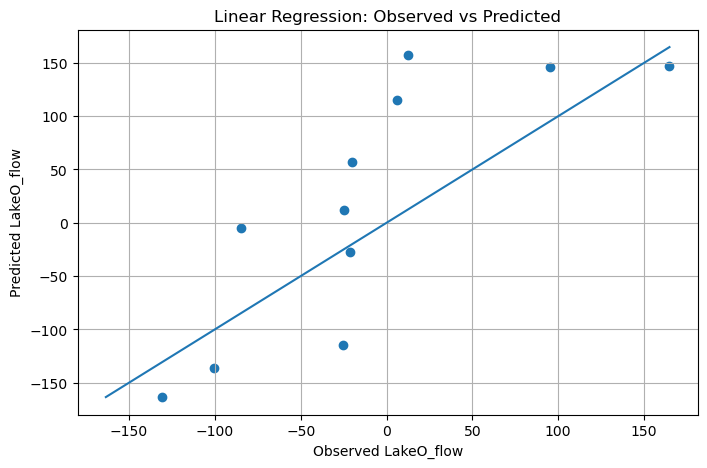

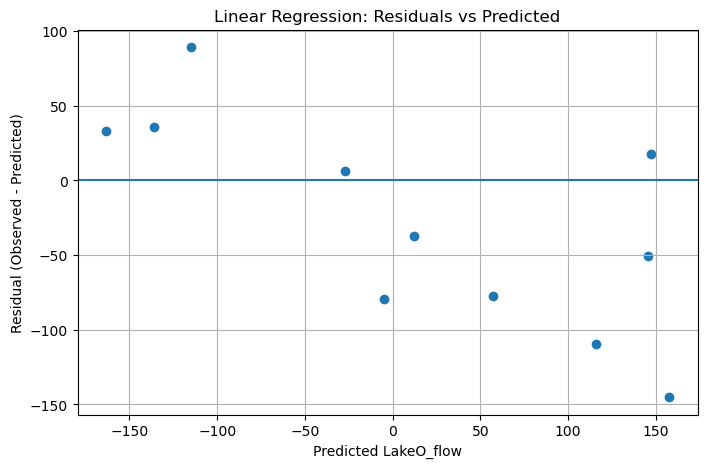

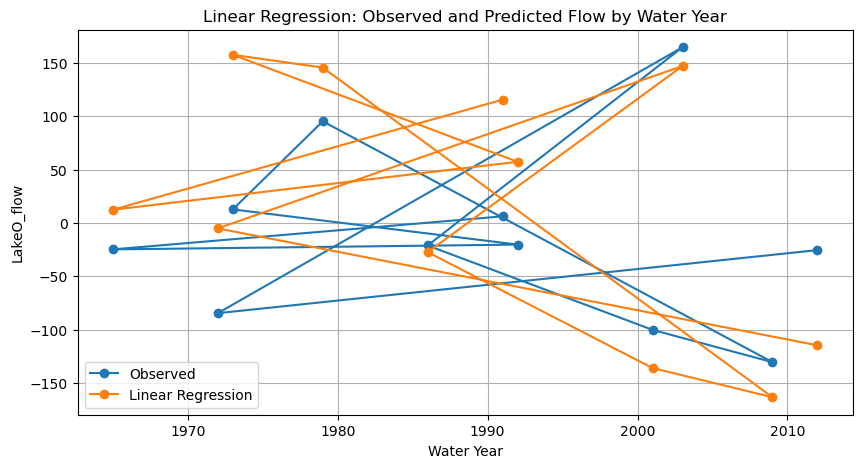

,Observed,Linear Regression
0,6.166667,115.639717
1,-24.833333,12.362959
2,-20.333333,57.355932
3,12.666667,157.713822
4,95.333333,145.707659
5,-130.666667,-163.522709
6,-100.333333,-136.151292
7,-21.166667,-27.424621
8,164.833333,147.211876
9,-84.666667,-5.121125


,Feature,Coefficient
0,LOK,84.198573
1,LKR,74.279867
2,ENSO_NINO.34,21.087779
3,AMO,12.487144
4,UKR,-12.335506
5,NAO,2.267575


In [23]:
plot_observed_vs_predicted(
    y_test,
    linear_pred,
    "Linear Regression: Observed vs Predicted"
)

plot_residuals(
    y_test,
    linear_pred,
    "Linear Regression: Residuals vs Predicted"
)

linear_test_years = model_df.loc[y_test.index, "WaterYear"].reset_index(drop=True)
linear_comparison_df = plot_test_set_predictions(
    y_test.reset_index(drop=True),
    {"Linear Regression": linear_pred},
    sample_labels=linear_test_years,
    title="Linear Regression: Observed and Predicted Flow by Water Year"
)

display(linear_comparison_df)

linear_coefficients = (
    pd.DataFrame({
        "Feature": X.columns,
        "Coefficient": linear_model.coef_
    })
    .sort_values("Coefficient", key=np.abs, ascending=False)
    .reset_index(drop=True)
)

display(linear_coefficients)

## 7) Logistic regression

Logistic regression is used for **classification**, not continuous prediction.

To make it useful in this water-resources example, we convert the seasonal
Lake Okeechobee flow into **three classes** based on the **training-set tertiles**:

- **Low flow** = at or below the lower tertile
- **Medium flow** = between the lower and upper tertiles
- **High flow** = above the upper tertile

This gives students a simple example of **multiclass classification** using the
same predictors that were used for the regression models.


In [50]:
# Create a 3-class target using the training-set tertiles only
low_threshold = y_train.quantile(1/3)
high_threshold = y_train.quantile(2/3)

def assign_flow_class(y, low_threshold, high_threshold):
    return pd.Series(
        np.where(
            y <= low_threshold,
            "Low flow",
            np.where(y <= high_threshold, "Medium flow", "High flow")
        ),
        index=y.index
    )

y_train_class = assign_flow_class(y_train, low_threshold, high_threshold)
y_test_class = assign_flow_class(y_test, low_threshold, high_threshold)

class_labels = ["Low flow", "Medium flow", "High flow"]

print(f"Low-flow threshold (33rd percentile):  {low_threshold:.3f}")
print(f"High-flow threshold (67th percentile): {high_threshold:.3f}")
print("\nClass balance in training set:")
display(y_train_class.value_counts().reindex(class_labels))

logistic_model = LogisticRegression(max_iter=2000)
logistic_model.fit(X_train, y_train_class)

logistic_pred = logistic_model.predict(X_test)
logistic_results = evaluate_classification_model(
    "Logistic Regression",
    y_test_class,
    logistic_pred
)


Low-flow threshold (33rd percentile):  -53.722
High-flow threshold (67th percentile): 76.444

Class balance in training set:


Low flow       15
Medium flow    14
High flow      15
Name: count, dtype: int64

Logistic Regression performance
  Accuracy = 0.545


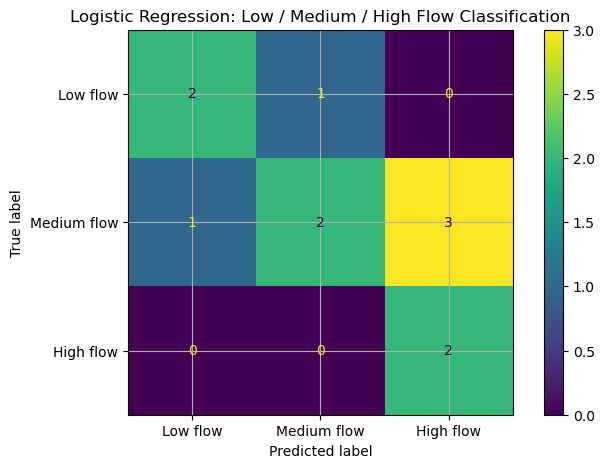

,High flow,Low flow,Medium flow
AMO,0.050231,-0.148088,0.097857
ENSO_NINO.34,0.606748,-0.386174,-0.220574
NAO,0.071601,-0.380901,0.309301
UKR,0.402274,-0.478189,0.075915
LKR,0.447941,-0.503642,0.055701
LOK,0.972056,-1.099057,0.127001


,Feature,Max |coefficient| across classes
0,LOK,1.099057
1,ENSO_NINO.34,0.606748
2,LKR,0.503642
3,UKR,0.478189
4,NAO,0.380901
5,AMO,0.148088


In [52]:
plot_confusion_matrix_for_classification(
    y_test_class,
    logistic_pred,
    "Logistic Regression: Low / Medium / High Flow Classification",
    class_labels
)

logistic_coefficients = pd.DataFrame(
    logistic_model.coef_.T,
    index=X.columns,
    columns=logistic_model.classes_
)

display(logistic_coefficients)

# Also show the strongest predictors based on the largest absolute coefficient
coefficient_strength = (
    logistic_coefficients.abs()
    .max(axis=1)
    .sort_values(ascending=False)
    .rename("Max |coefficient| across classes")
    .reset_index()
    .rename(columns={"index": "Feature"})
)

display(coefficient_strength)


## 8) Random Forest regression

Random Forest is a useful baseline because it is usually stable and easy to interpret.


In [55]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_results = evaluate_regression_model("Random Forest", y_test, rf_pred)


Random Forest performance
  R²   = 0.663
  RMSE = 46.781


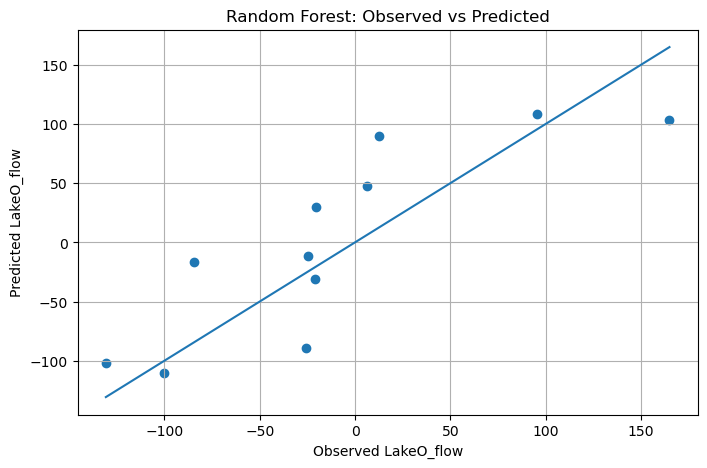

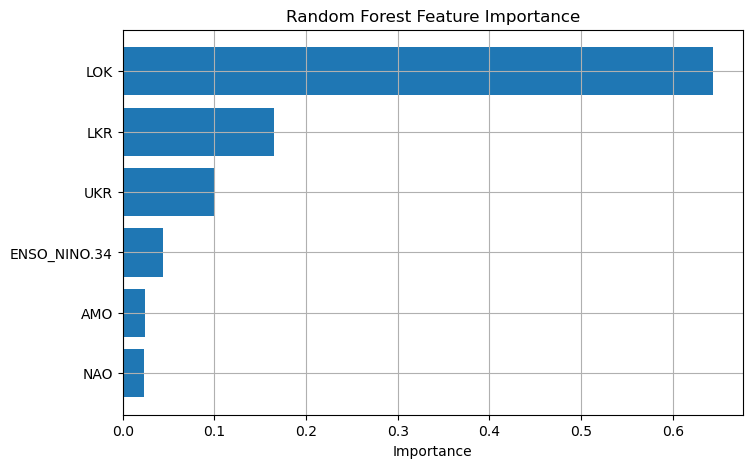

,Feature,Importance
0,LOK,0.644028
1,LKR,0.165232
2,UKR,0.099762
3,ENSO_NINO.34,0.043536
4,AMO,0.024770
5,NAO,0.022673


In [57]:
plot_observed_vs_predicted(
    y_test,
    rf_pred,
    "Random Forest: Observed vs Predicted"
)

rf_importance = plot_feature_importance(
    rf_model.feature_importances_,
    X.columns,
    "Random Forest Feature Importance"
)

display(rf_importance)


## 8a) Random Forest uncertainty bounds on the test set

The Random Forest interval below uses the spread of the individual trees to show a plausible range around each test-set prediction.

Random Forest uncertainty summary
  Interval coverage = 0.909
  Mean interval width = 174.511


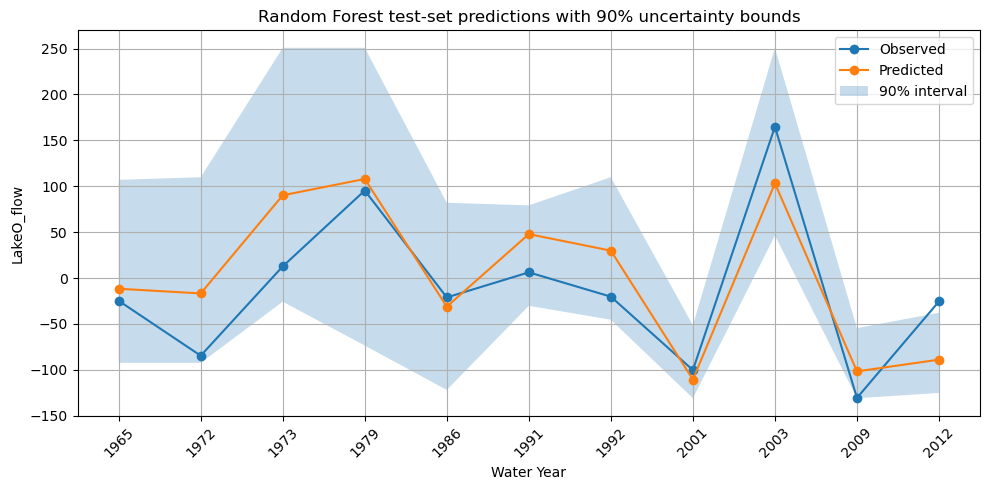

,Model,Coverage,Mean_Interval_Width
0,Random Forest,0.909091,174.510606


,WaterYear,Observed,RF_Prediction,RF_Lower_5,RF_Upper_95,RF_Interval_Width
0,1965,-24.833333,-11.695556,-92.500000,107.000000,199.500000
1,1972,-84.666667,-16.809444,-92.500000,109.833333,202.333333
2,1973,12.666667,90.158333,-25.833333,250.833333,276.666667
3,1979,95.333333,107.935278,-73.666667,250.833333,324.500000
4,1986,-21.166667,-31.203333,-122.000000,82.000000,204.000000
5,1991,6.166667,47.848889,-30.333333,79.166667,109.500000
6,1992,-20.333333,29.797222,-45.483333,109.833333,155.316667
7,2001,-100.333333,-110.680000,-131.000000,-51.500000,79.500000
8,2003,164.833333,103.148333,46.333333,250.833333,204.500000
9,2009,-130.666667,-101.738333,-131.000000,-54.666667,76.333333


In [60]:
# Estimate a 90% prediction interval for the Random Forest test predictions
rf_interval_df = compute_rf_prediction_intervals(
    rf_model,
    X_test,
    lower_q=5,
    upper_q=95,
)

rf_uncertainty_results = summarize_prediction_intervals(
    "Random Forest",
    y_test,
    rf_interval_df["Lower_5"],
    rf_interval_df["Upper_95"],
)

rf_years = model_df.loc[X_test.index, "WaterYear"]
rf_order = np.argsort(rf_years.to_numpy())

rf_interval_plot_df = pd.DataFrame(
    {
        "WaterYear": rf_years.iloc[rf_order].to_numpy(),
        "Observed": y_test.iloc[rf_order].to_numpy(),
        "RF_Prediction": rf_interval_df.loc[X_test.index, "Prediction"].to_numpy()[rf_order],
        "RF_Lower_5": rf_interval_df.loc[X_test.index, "Lower_5"].to_numpy()[rf_order],
        "RF_Upper_95": rf_interval_df.loc[X_test.index, "Upper_95"].to_numpy()[rf_order],
        "RF_Interval_Width": rf_interval_df.loc[X_test.index, "Interval_Width"].to_numpy()[rf_order],
    }
).reset_index(drop=True)

plot_predictions_with_intervals(
    rf_interval_plot_df["Observed"],
    rf_interval_plot_df["RF_Prediction"],
    rf_interval_plot_df["RF_Lower_5"],
    rf_interval_plot_df["RF_Upper_95"],
    sample_labels=rf_interval_plot_df["WaterYear"],
    title="Random Forest test-set predictions with 90% uncertainty bounds",
)

display(pd.DataFrame([rf_uncertainty_results]))
display(rf_interval_plot_df)

## 9) Hyperparameter tuning for Random Forest with grid search

In the baseline Random Forest model above, we manually selected a few parameter values. A **hyperparameter** is a setting that controls how the model learns, such as the number of trees or the maximum tree depth.

Here we use **GridSearchCV**, which tries many parameter combinations on the **training set only** and uses cross-validation to estimate which combination performs best. For this classroom demonstration, the grid is intentionally small so it runs in a reasonable time.

In [63]:
# Keep the search grid small for classroom demonstration purposes
rf_param_grid = {
    "n_estimators": [100, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
}

rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=rf_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=1,
    verbose=1,
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest parameters:")
print(rf_grid.best_params_)
print(f"Best cross-validated RMSE: {-rf_grid.best_score_:.3f}")

rf_grid_results = summarize_grid_search_results(rf_grid, top_n=10)
display(rf_grid_results)

rf_tuned_model = rf_grid.best_estimator_
rf_tuned_pred = rf_tuned_model.predict(X_test)
rf_tuned_results = evaluate_regression_model("Random Forest (tuned)", y_test, rf_tuned_pred)


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Random Forest parameters:
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best cross-validated RMSE: 79.104


,rank_test_score,CV_RMSE,std_test_score,params
0,1,79.104135,20.192493,"{'max_depth': 5, 'min_samples_leaf': 1, 'min_s..."
1,2,79.750800,20.541636,"{'max_depth': None, 'min_samples_leaf': 1, 'mi..."
2,3,79.774473,20.570316,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_..."
3,4,80.096564,20.884247,"{'max_depth': 5, 'min_samples_leaf': 1, 'min_s..."
4,5,80.260696,20.867319,"{'max_depth': None, 'min_samples_leaf': 1, 'mi..."
5,5,80.260696,20.867319,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_..."
6,7,81.222727,20.826358,"{'max_depth': 5, 'min_samples_leaf': 1, 'min_s..."
7,8,82.421587,20.663147,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_..."
8,9,82.422418,20.664184,"{'max_depth': None, 'min_samples_leaf': 1, 'mi..."
9,10,82.706212,24.965311,"{'max_depth': None, 'min_samples_leaf': 2, 'mi..."


Random Forest (tuned) performance
  R²   = 0.677
  RMSE = 45.751


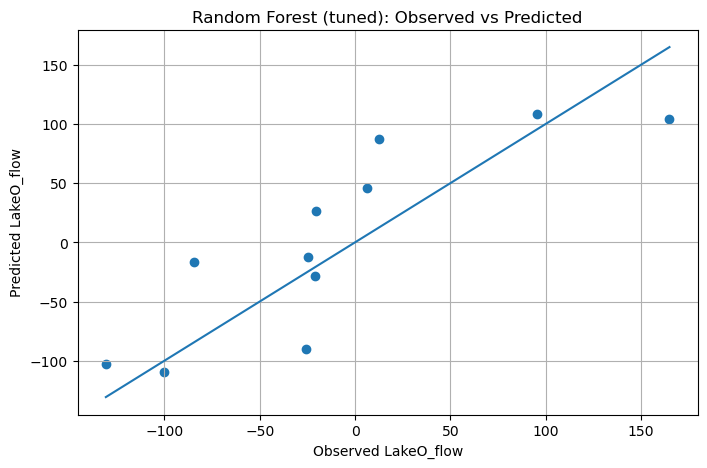

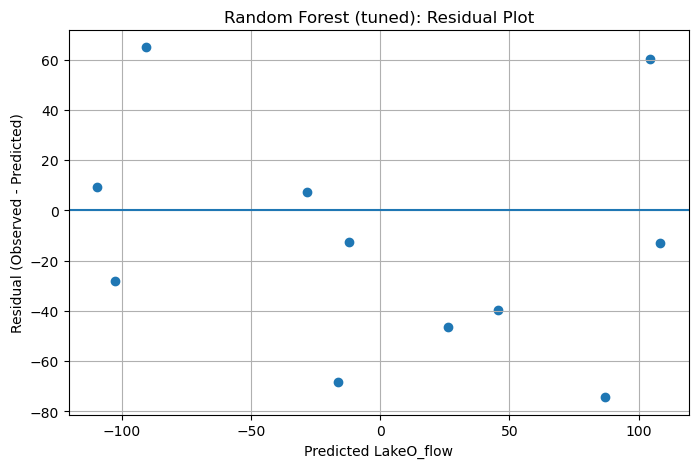

In [64]:
plot_observed_vs_predicted(
    y_test,
    rf_tuned_pred,
    "Random Forest (tuned): Observed vs Predicted"
)

plot_residuals(
    y_test,
    rf_tuned_pred,
    "Random Forest (tuned): Residual Plot"
)


## 10) XGBoost regression

In [66]:
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=1,
    verbosity=0
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

xgb_results = evaluate_regression_model("XGBoost", y_test, xgb_pred)


XGBoost performance
  R²   = 0.698
  RMSE = 44.297


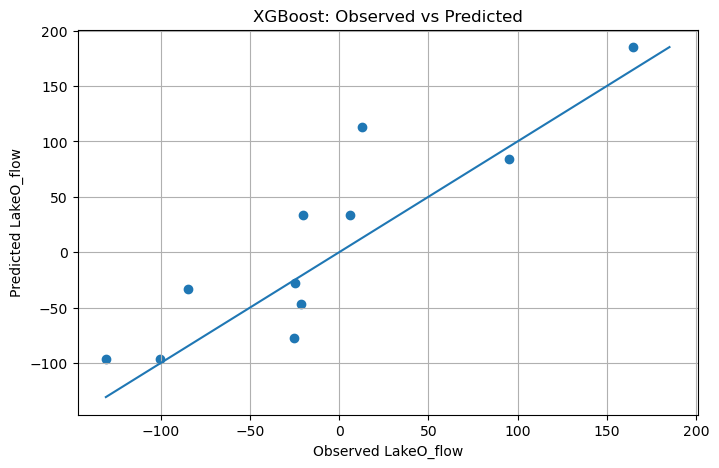

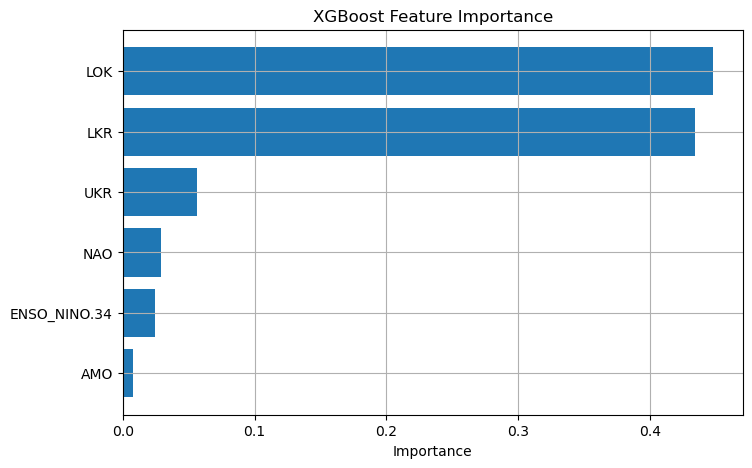

,Feature,Importance
0,LOK,0.447907
1,LKR,0.434096
2,UKR,0.056462
3,NAO,0.028999
4,ENSO_NINO.34,0.024805
5,AMO,0.007730


In [67]:
plot_observed_vs_predicted(
    y_test,
    xgb_pred,
    "XGBoost: Observed vs Predicted"
)

xgb_importance = plot_feature_importance(
    xgb_model.feature_importances_,
    X.columns,
    "XGBoost Feature Importance"
)

display(xgb_importance)


## 10a) XGBoost uncertainty bounds on the test set

XGBoost does not provide the same tree-by-tree prediction spread as Random Forest, so here we build a small bootstrap ensemble and use the spread across the repeated fits as the uncertainty range.

XGBoost uncertainty summary
  Interval coverage = 0.545
  Mean interval width = 97.585


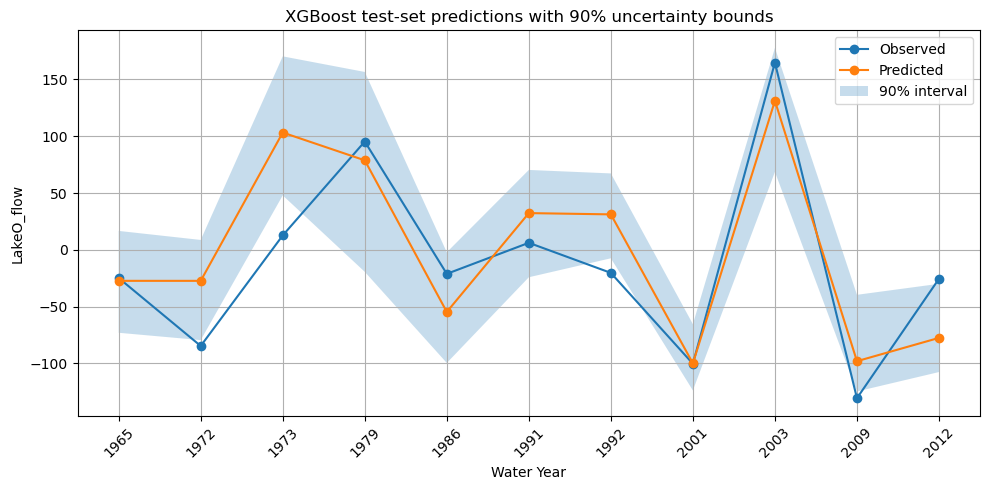

,Model,Coverage,Mean_Interval_Width
0,XGBoost,0.545455,97.585079


,WaterYear,Observed,XGB_Prediction,XGB_Lower_5,XGB_Upper_95,XGB_Interval_Width
0,1965,-24.833333,-27.324249,-73.061802,16.633645,89.695446
1,1972,-84.666667,-27.339388,-79.511269,8.686806,88.198075
2,1973,12.666667,103.237305,47.902642,170.324164,122.421522
3,1979,95.333333,78.791626,-19.398721,156.594152,175.992873
4,1986,-21.166667,-54.695339,-99.629530,-2.179364,97.450167
5,1991,6.166667,32.314529,-24.173526,70.320452,94.493978
6,1992,-20.333333,31.187132,-7.477909,67.257302,74.735211
7,2001,-100.333333,-99.951317,-123.839192,-65.455539,58.383653
8,2003,164.833333,131.165848,68.555947,177.817413,109.261466
9,2009,-130.666667,-98.070137,-124.728683,-39.626870,85.101813


In [69]:
# Estimate a 90% prediction interval for the XGBoost test predictions
# using a bootstrap ensemble of repeated model fits.
xgb_interval_df, xgb_ensemble_predictions = compute_bootstrap_prediction_intervals(
    xgb_model,
    X_train,
    y_train,
    X_test,
    n_members=30,
    lower_q=5,
    upper_q=95,
    random_state=42,
)

xgb_uncertainty_results = summarize_prediction_intervals(
    "XGBoost",
    y_test,
    xgb_interval_df["Lower_5"],
    xgb_interval_df["Upper_95"],
)

xgb_years = model_df.loc[X_test.index, "WaterYear"]
xgb_order = np.argsort(xgb_years.to_numpy())

xgb_interval_plot_df = pd.DataFrame(
    {
        "WaterYear": xgb_years.iloc[xgb_order].to_numpy(),
        "Observed": y_test.iloc[xgb_order].to_numpy(),
        "XGB_Prediction": xgb_interval_df.loc[X_test.index, "Prediction"].to_numpy()[xgb_order],
        "XGB_Lower_5": xgb_interval_df.loc[X_test.index, "Lower_5"].to_numpy()[xgb_order],
        "XGB_Upper_95": xgb_interval_df.loc[X_test.index, "Upper_95"].to_numpy()[xgb_order],
        "XGB_Interval_Width": xgb_interval_df.loc[X_test.index, "Interval_Width"].to_numpy()[xgb_order],
    }
).reset_index(drop=True)

plot_predictions_with_intervals(
    xgb_interval_plot_df["Observed"],
    xgb_interval_plot_df["XGB_Prediction"],
    xgb_interval_plot_df["XGB_Lower_5"],
    xgb_interval_plot_df["XGB_Upper_95"],
    sample_labels=xgb_interval_plot_df["WaterYear"],
    title="XGBoost test-set predictions with 90% uncertainty bounds",
)

display(pd.DataFrame([xgb_uncertainty_results]))
display(xgb_interval_plot_df)

## 11) Hyperparameter tuning for XGBoost with grid search

XGBoost often performs very well, but it is also sensitive to hyperparameters such as **learning rate**, **tree depth**, and **number of trees**. Grid search helps us test several combinations systematically instead of guessing.

As with the Random Forest example, we tune the model using only the training data and keep the grid compact for demonstration.

In [71]:
# Keep the search grid small enough for classroom use
xgb_param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.10],
    "max_depth": [3, 4, 5],
    "subsample": [0.8, 0.9],
    "colsample_bytree": [0.8, 0.9],
}

xgb_grid = GridSearchCV(
    estimator=XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=1,
        verbosity=0,
    ),
    param_grid=xgb_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=1,
    verbose=1,
)

xgb_grid.fit(X_train, y_train)

print("Best XGBoost parameters:")
print(xgb_grid.best_params_)
print(f"Best cross-validated RMSE: {-xgb_grid.best_score_:.3f}")

xgb_grid_results = summarize_grid_search_results(xgb_grid, top_n=10)
display(xgb_grid_results)

xgb_tuned_model = xgb_grid.best_estimator_
xgb_tuned_pred = xgb_tuned_model.predict(X_test)
xgb_tuned_results = evaluate_regression_model("XGBoost (tuned)", y_test, xgb_tuned_pred)


Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best XGBoost parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
Best cross-validated RMSE: 93.763


,rank_test_score,CV_RMSE,std_test_score,params
0,1,93.763043,37.023499,"{'colsample_bytree': 0.8, 'learning_rate': 0.0..."
1,2,93.856259,36.206495,"{'colsample_bytree': 0.8, 'learning_rate': 0.1..."
2,3,93.872828,36.124251,"{'colsample_bytree': 0.8, 'learning_rate': 0.1..."
3,4,93.911042,36.554170,"{'colsample_bytree': 0.8, 'learning_rate': 0.0..."
4,5,93.959819,37.240743,"{'colsample_bytree': 0.8, 'learning_rate': 0.0..."
5,6,94.151119,36.054115,"{'colsample_bytree': 0.8, 'learning_rate': 0.1..."
6,7,94.153384,36.561708,"{'colsample_bytree': 0.9, 'learning_rate': 0.1..."
7,8,94.715028,39.971169,"{'colsample_bytree': 0.9, 'learning_rate': 0.0..."
8,9,94.778331,36.854179,"{'colsample_bytree': 0.8, 'learning_rate': 0.1..."
9,10,94.825067,37.806175,"{'colsample_bytree': 0.8, 'learning_rate': 0.0..."


XGBoost (tuned) performance
  R²   = 0.585
  RMSE = 51.922


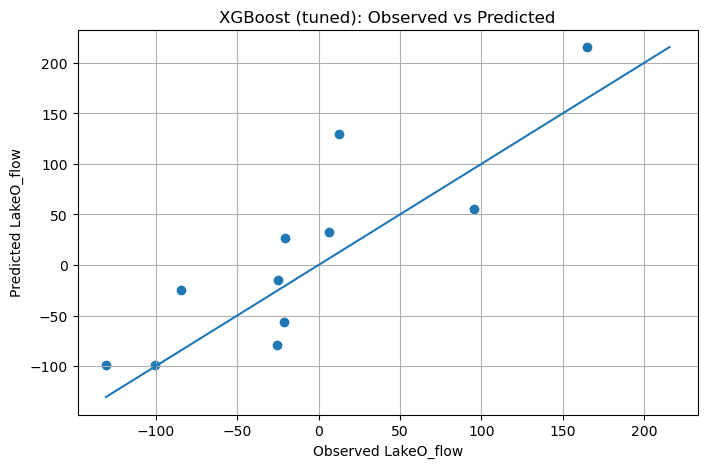

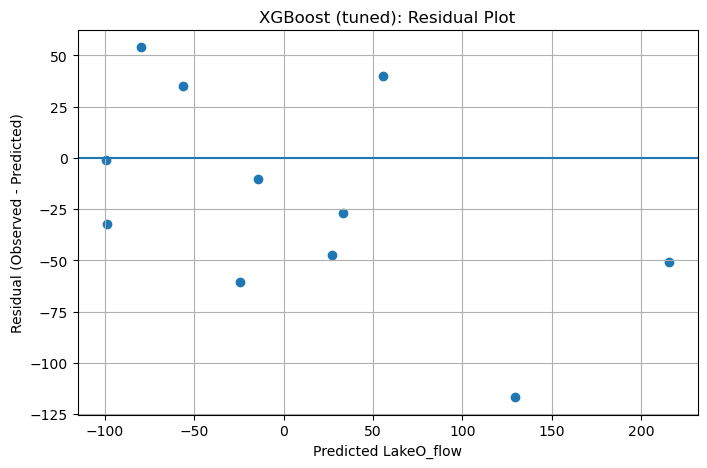

In [72]:
plot_observed_vs_predicted(
    y_test,
    xgb_tuned_pred,
    "XGBoost (tuned): Observed vs Predicted"
)

plot_residuals(
    y_test,
    xgb_tuned_pred,
    "XGBoost (tuned): Residual Plot"
)


## 12) Compare the models at the end

,Model,R2,RMSE
0,XGBoost,0.697663,44.297334
1,Random Forest (tuned),0.677495,45.750957
2,Random Forest,0.662811,46.780945
3,XGBoost (tuned),0.584622,51.922306
4,Linear Regression,0.159570,73.855507


,Model,Best_CV_RMSE,max_depth,min_samples_leaf,min_samples_split,n_estimators,colsample_bytree,learning_rate,subsample
0,Random Forest (tuned),79.104135,5,1.0,2.0,300,NaN,NaN,NaN
1,XGBoost (tuned),93.763043,5,NaN,NaN,100,0.8,0.05,0.8


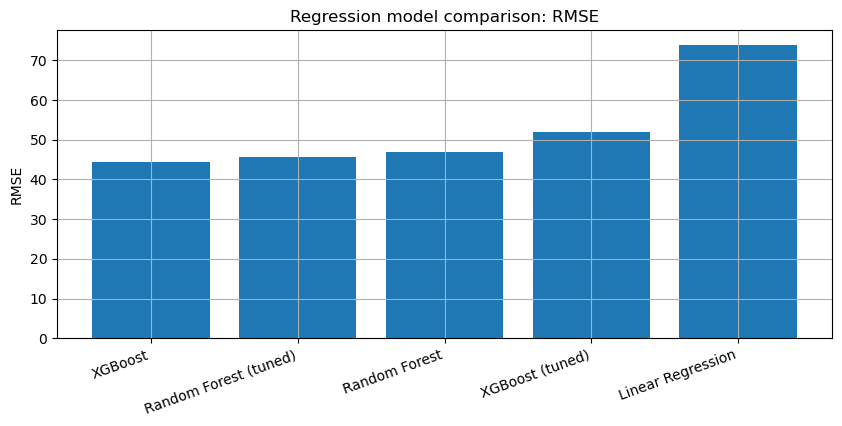

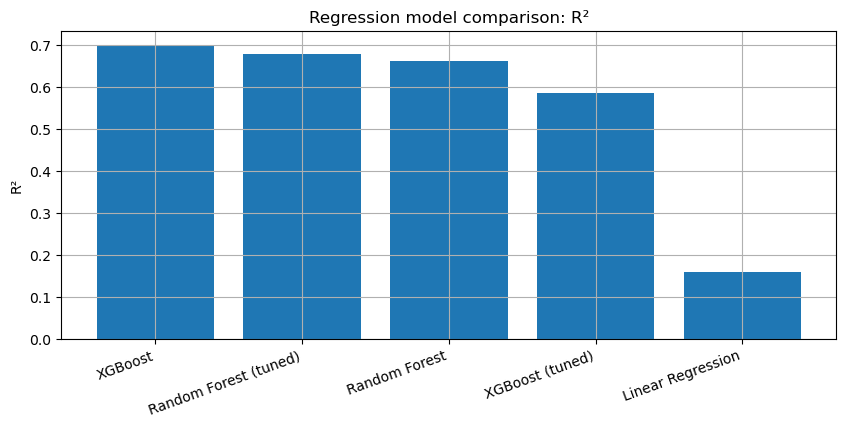

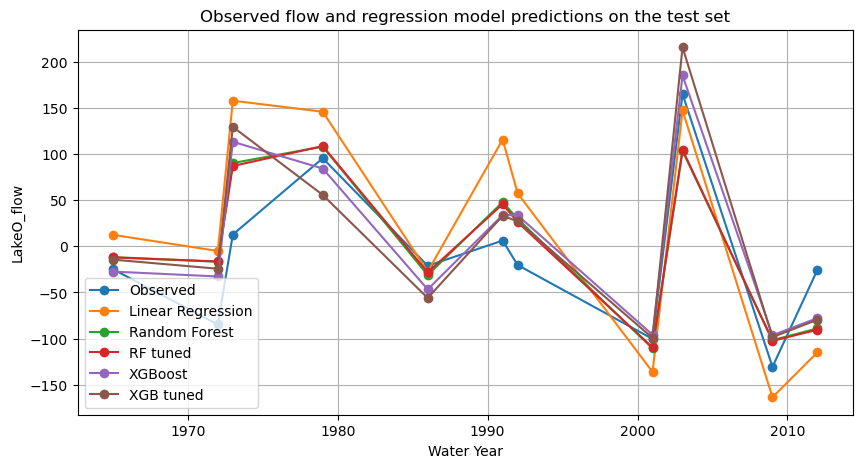

,Observed,Linear Regression,Random Forest,RF tuned,XGBoost,XGB tuned
0,-24.833333,12.362959,-11.695556,-12.144499,-27.419466,-14.465104
1,-84.666667,-5.121125,-16.809444,-16.434420,-32.725235,-24.342031
2,12.666667,157.713822,90.158333,86.941732,113.158768,129.333481
3,95.333333,145.707659,107.935278,108.490196,84.177971,55.597954
4,-21.166667,-27.424621,-31.203333,-28.350345,-46.733353,-56.042336
5,6.166667,115.639717,47.848889,45.640940,33.843357,32.970295
6,-20.333333,57.355932,29.797222,26.078319,33.507523,27.046190
7,-100.333333,-136.151292,-110.680000,-109.628167,-95.886780,-99.354950
8,164.833333,147.211876,103.148333,104.433494,185.061996,215.608170
9,-130.666667,-163.522709,-101.738333,-102.419175,-96.373184,-98.432068


,Model,Coverage,Mean_Interval_Width
0,Random Forest,0.909091,174.510606
1,XGBoost,0.545455,97.585079


,Model,Accuracy
0,Logistic Regression,0.545455


Logistic Regression is not directly comparable to the regression models because it predicts low / medium / high flow classes instead of a continuous flow value.


In [74]:
# Regression metrics table including baseline and tuned models
comparison_df = pd.DataFrame(
    [
        linear_results,
        rf_results,
        rf_tuned_results,
        xgb_results,
        xgb_tuned_results,
    ]
).sort_values("RMSE").reset_index(drop=True)

display(comparison_df)

# Summarize the best tuning choices from the two grid searches
best_param_summary = pd.DataFrame([
    {
        "Model": "Random Forest (tuned)",
        "Best_CV_RMSE": -rf_grid.best_score_,
        **rf_grid.best_params_,
    },
    {
        "Model": "XGBoost (tuned)",
        "Best_CV_RMSE": -xgb_grid.best_score_,
        **xgb_grid.best_params_,
    },
])

display(best_param_summary)

# Bar charts for regression metrics
plt.figure(figsize=(10, 4))
plt.bar(comparison_df["Model"], comparison_df["RMSE"])
plt.ylabel("RMSE")
plt.title("Regression model comparison: RMSE")
plt.xticks(rotation=20, ha="right")
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(comparison_df["Model"], comparison_df["R2"])
plt.ylabel("R²")
plt.title("Regression model comparison: R²")
plt.xticks(rotation=20, ha="right")
plt.show()

# Put all regression predictions on one plot for the same test samples
comparison_years = model_df.loc[y_test.index, "WaterYear"]
comparison_order = np.argsort(comparison_years.to_numpy())
sorted_years = comparison_years.iloc[comparison_order].reset_index(drop=True)
sorted_y_test = y_test.iloc[comparison_order].reset_index(drop=True)

regression_prediction_df = plot_test_set_predictions(
    sorted_y_test,
    {
        "Linear Regression": np.asarray(linear_pred)[comparison_order],
        "Random Forest": np.asarray(rf_pred)[comparison_order],
        "RF tuned": np.asarray(rf_tuned_pred)[comparison_order],
        "XGBoost": np.asarray(xgb_pred)[comparison_order],
        "XGB tuned": np.asarray(xgb_tuned_pred)[comparison_order],
    },
    sample_labels=sorted_years,
    title="Observed flow and regression model predictions on the test set"
)

display(regression_prediction_df)


# Uncertainty interval summary for the two tree-based regression methods
uncertainty_comparison_df = pd.DataFrame(
    [
        rf_uncertainty_results,
        xgb_uncertainty_results,
    ]
)
display(uncertainty_comparison_df)

# Classification result shown separately because it is a different modeling task
classification_comparison_df = pd.DataFrame([logistic_results])
display(classification_comparison_df)

print(
    "Logistic Regression is not directly comparable to the regression models "
    "because it predicts low / medium / high flow classes instead of a continuous flow value."
)
